SNR= 0 dB | BER=1.4761e-01 | INT=1.4569e-01 | FEC_SI=1.7548e-01 | FEC_INT=1.7876e-01
SNR= 2 dB | BER=1.0805e-01 | INT=1.0509e-01 | FEC_SI=1.2069e-01 | FEC_INT=6.9980e-02
SNR= 4 dB | BER=8.4850e-02 | INT=8.1320e-02 | FEC_SI=7.8810e-02 | FEC_INT=2.6180e-02
SNR= 6 dB | BER=5.2360e-02 | INT=5.4540e-02 | FEC_SI=5.1490e-02 | FEC_INT=1.0420e-02
SNR= 8 dB | BER=3.6080e-02 | INT=3.5080e-02 | FEC_SI=3.3930e-02 | FEC_INT=2.2400e-03
SNR=10 dB | BER=2.1230e-02 | INT=2.0690e-02 | FEC_SI=2.2230e-02 | FEC_INT=2.4000e-04
SNR=12 dB | BER=1.5340e-02 | INT=1.6390e-02 | FEC_SI=1.3300e-02 | FEC_INT=1.8000e-04
SNR=14 dB | BER=1.1540e-02 | INT=9.7200e-03 | FEC_SI=9.5900e-03 | FEC_INT=6.0000e-05


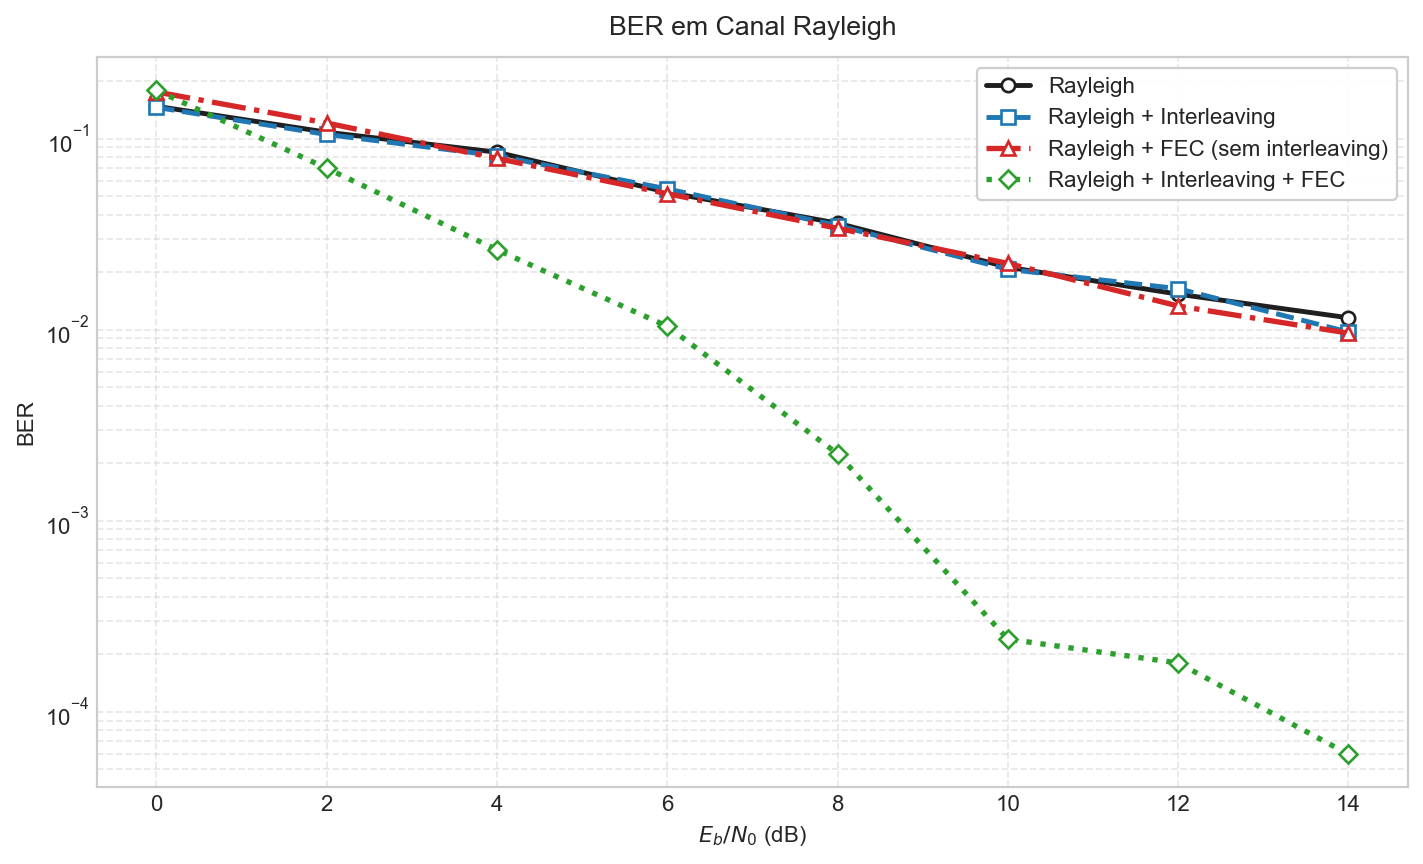

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# PARÂMETROS
# ==========================================================

N_BITS = 100000
EBN0_DB = np.arange(0, 16, 2)

# tamanho do bloco de fading
FADE_BLOCK = 100

# tamanho do interleaver
INTERLEAVER_ROWS = 100

# ==========================================================
# FUNÇÕES AUXILIARES
# ==========================================================

def bpsk_mod(bits):
    return 2 * bits - 1


def awgn(signal, ebn0_db):

    ebn0 = 10**(ebn0_db / 10)

    noise_var = 1 / (2 * ebn0)

    noise = np.sqrt(noise_var) * (
        np.random.randn(len(signal))
    )

    return signal + noise


def rayleigh_block_fading(signal, block_size):

    n = len(signal)

    faded = np.zeros_like(signal, dtype=float)

    idx = 0

    while idx < n:

        h = np.sqrt(
            np.random.randn()**2 +
            np.random.randn()**2
        ) / np.sqrt(2)

        end = min(idx + block_size, n)

        faded[idx:end] = h * signal[idx:end]

        idx = end

    return faded


def detect(rx):
    return (rx > 0).astype(int)


def ber(tx_bits, rx_bits):
    return np.mean(tx_bits != rx_bits)


# ==========================================================
# BLOCK INTERLEAVER
# ==========================================================

def interleave(bits, rows):

    cols = len(bits) // rows

    bits = bits[:rows * cols]

    mat = bits.reshape(rows, cols)

    return mat.T.flatten()


def deinterleave(bits, rows):

    cols = len(bits) // rows

    mat = bits.reshape(cols, rows)

    return mat.T.flatten()


# ==========================================================
# CÓDIGO CONVOLUCIONAL (rate 1/2)
# g0 = 111
# g1 = 101
# ==========================================================

def conv_encode(bits):

    s1 = 0
    s2 = 0

    encoded = []

    for b in bits:

        g0 = b ^ s1 ^ s2
        g1 = b ^ s2

        encoded.extend([g0, g1])

        s2 = s1
        s1 = b

    return np.array(encoded)


def hard_viterbi_decode(rx_bits):

    n_states = 4

    trellis = {}

    for state in range(n_states):

        s1 = (state >> 1) & 1
        s2 = state & 1

        for inp in [0, 1]:

            g0 = inp ^ s1 ^ s2
            g1 = inp ^ s2

            next_state = ((inp << 1) | s1)

            trellis[(state, inp)] = (
                next_state,
                np.array([g0, g1])
            )

    n_steps = len(rx_bits) // 2

    metric = np.ones(n_states) * 1e9
    metric[0] = 0

    paths = np.zeros((n_steps + 1, n_states),
                     dtype=int)

    for k in range(n_steps):

        r = rx_bits[2*k:2*k+2]

        new_metric = np.ones(n_states) * 1e9

        for state in range(n_states):

            if metric[state] >= 1e8:
                continue

            for inp in [0, 1]:

                next_state, out = trellis[(state, inp)]

                dist = np.sum(out != r)

                cand = metric[state] + dist

                if cand < new_metric[next_state]:

                    new_metric[next_state] = cand
                    paths[k+1, next_state] = (
                        state * 2 + inp
                    )

        metric = new_metric

    state = np.argmin(metric)

    decoded = []

    for k in range(n_steps, 0, -1):

        prev = paths[k, state]

        inp = prev & 1

        decoded.append(inp)

        state = prev >> 1

    decoded.reverse()

    return np.array(decoded)


# ==========================================================
# SIMULAÇÃO
# ==========================================================

ber_rayleigh = []
ber_inter = []
ber_fec_no_inter = []
ber_fec = []

for snr in EBN0_DB:

    # ----------------------------------
    # bits aleatórios
    # ----------------------------------

    bits = np.random.randint(0, 2, N_BITS)

    # ==================================
    # CASO 1
    # Rayleigh sem interleaving
    # ==================================

    tx = bpsk_mod(bits)

    faded = rayleigh_block_fading(
        tx,
        FADE_BLOCK
    )

    rx = awgn(faded, snr)

    det = detect(rx)

    ber_rayleigh.append(
        ber(bits, det)
    )

    # ==================================
    # CASO 2
    # Rayleigh + Interleaving
    # ==================================

    inter_bits = interleave(
        bits,
        INTERLEAVER_ROWS
    )

    tx = bpsk_mod(inter_bits)

    faded = rayleigh_block_fading(
        tx,
        FADE_BLOCK
    )

    rx = awgn(faded, snr)

    det = detect(rx)

    det = deinterleave(
        det,
        INTERLEAVER_ROWS
    )

    ber_inter.append(
        ber(bits[:len(det)], det)
    )

    # ==================================
    # CASO 3
    # Rayleigh + FEC (sem interleaving)
    # ==================================

    encoded = conv_encode(bits)

    tx = bpsk_mod(encoded)

    faded = rayleigh_block_fading(
        tx,
        FADE_BLOCK
    )

    rx = awgn(faded, snr)

    det = detect(rx)

    decoded = hard_viterbi_decode(det)

    m = min(len(bits), len(decoded))

    ber_fec_no_inter.append(
        ber(bits[:m], decoded[:m])
    )

    # ==================================
    # CASO 4
    # Rayleigh + Interleaving + FEC
    # ==================================

    encoded = conv_encode(bits)

    encoded = interleave(
        encoded,
        INTERLEAVER_ROWS
    )

    tx = bpsk_mod(encoded)

    faded = rayleigh_block_fading(
        tx,
        FADE_BLOCK
    )

    rx = awgn(faded, snr)

    det = detect(rx)

    det = deinterleave(
        det,
        INTERLEAVER_ROWS
    )

    decoded = hard_viterbi_decode(det)

    m = min(len(bits), len(decoded))

    ber_fec.append(
        ber(bits[:m], decoded[:m])
    )

    print(
        f"SNR={snr:2d} dB | "
        f"BER={ber_rayleigh[-1]:.4e} | "
        f"INT={ber_inter[-1]:.4e} | "
        f"FEC_SI={ber_fec_no_inter[-1]:.4e} | "
        f"FEC_INT={ber_fec[-1]:.4e}"
    )

# ==========================================================
# GRÁFICO
# ==========================================================

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(9, 5.5), dpi=160)

plt.semilogy(
    EBN0_DB, ber_rayleigh,
    color='#1f1f1f', linestyle='-',
    marker='o', markersize=6, linewidth=2.2,
    markerfacecolor='white', markeredgewidth=1.2,
    label='Rayleigh'
)

plt.semilogy(
    EBN0_DB, ber_inter,
    color='#1f77b4', linestyle='--',
    marker='s', markersize=6, linewidth=2.2,
    markerfacecolor='white', markeredgewidth=1.2,
    label='Rayleigh + Interleaving'
)

plt.semilogy(
    EBN0_DB, ber_fec_no_inter,
    color='#d62728', linestyle='-.',
    marker='^', markersize=6, linewidth=2.4,
    markerfacecolor='white', markeredgewidth=1.2,
    label='Rayleigh + FEC (sem interleaving)'
)

plt.semilogy(
    EBN0_DB, ber_fec,
    color='#2ca02c', linestyle=':',
    marker='D', markersize=6, linewidth=2.4,
    markerfacecolor='white', markeredgewidth=1.2,
    label='Rayleigh + Interleaving + FEC'
)

plt.grid(True, which='both', linestyle='--', alpha=0.45)
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.title('BER em Canal Rayleigh', pad=10)
plt.legend(frameon=True, facecolor='white', framealpha=0.95)
plt.tight_layout()